# Example-11: Iterative decomposition

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

[2.]
[0.12 1.   0.1 ]
[0.24  0.005 0.01 ]
[3.6e-01 1.0e-04 1.0e-05]


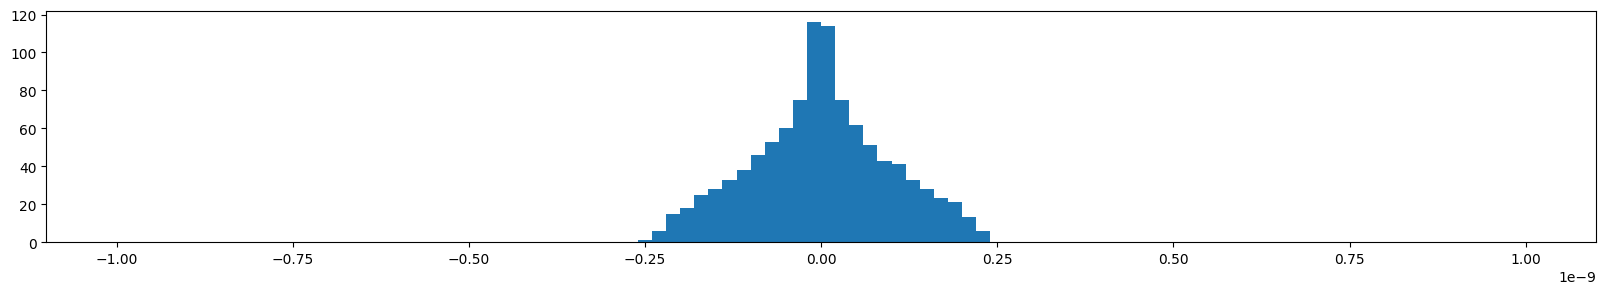

9.731337653646109e-11


In [3]:
# Set parameters

size, length = 1, 1024

# Set window

w = Window.from_cosine(length, order=4.0, dtype=dtype, device=device)

# Set data

t  = torch.linspace(0.0, length-1, length, dtype=dtype, device=device)
data  = 1.0000*torch.cos(2.0*numpy.pi*1*0.12*t) + 0.10000*torch.sin(2.0*numpy.pi*1*0.12*t)
data += 0.0050*torch.cos(2.0*numpy.pi*2*0.12*t) + 0.01000*torch.sin(2.0*numpy.pi*2*0.12*t)
data += 0.0001*torch.cos(2.0*numpy.pi*3*0.12*t) + 0.00001*torch.sin(2.0*numpy.pi*3*0.12*t)
data += 2.0
data  = torch.stack([data])
d = Data.from_data(w, data)

# Compute (window weighted) mean value

print(d.window_mean().flatten().cpu().numpy())

# Remove (window weighted) mean value
# Note, mean is removed from work

d.window_remove_mean()
d.data.copy_(d.work)

# Initialize Frequency instance

f = Frequency(d)

# Perform decomposition (component-by-component subtraction)

for _ in range(3):
    
    # Remove mean and apply window
    
    d.window_apply()
    
    # Estimate main harmonic frequency
    
    f('parabola')
    frequency = f.frequency[0]
    
    # Estimate main harmonic parameters
    
    cos = 2.0*torch.dot(d.data[0]*w.window, torch.cos(2.0*numpy.pi*frequency*t))/w.total
    sin = 2.0*torch.dot(d.data[0]*w.window, torch.sin(2.0*numpy.pi*frequency*t))/w.total
    
    # Subtract harmonic
    
    harmonic = cos*torch.cos(2.0*numpy.pi*frequency*t) + sin*torch.sin(2.0*numpy.pi*frequency*t)
    d.data.sub_(harmonic)
    
    # Reset work
    
    d.reset()
    
    # Print result
    
    print(torch.stack([frequency, cos, sin]).cpu().numpy())
    

# Plot residual

plt.figure(figsize=(20, 3))
plt.hist(d.data[0].cpu().numpy(), bins=100, range=(-1.0E-9, +1.0E-9))
plt.show()

# Residual spread

print(d.data.std().item())

# Clean

del w
del t, data
del d
del f
if device != torch.device('cpu'):
    torch.cuda.synchronize()
    torch.cuda.empty_cache()